# BPSK Signal Flow Analysis

**Monica Joya - ITAI 4370 - Laboratory 01 (Part 2)**

This notebook follows one short message as it travels through the communication system from Part 1: Source (Bits), Modulator, Channel, Demodulator, and Receiver (Bits). At each stage we plot the signal and explain what is happening, so we can watch raw bits turn into a wave, survive a noisy channel, and come back out as bits.

The method is BPSK, short for Binary Phase Shift Keying. It is the simplest way to carry bits on a wave. The information lives in the phase of the wave, that is, in which way up the wave sits, rather than in its loudness or its pitch.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Used a fixed seed so the random bits and noise are the same every run
np.random.seed(42)

# Parameters
num_bits = 20   # number of bits in the message
fc = 5          # carrier frequency in Hz
fs = 500        # samples per bit, controls how smooth the wave looks
t = np.linspace(0, num_bits, num_bits * fs)

## Stage 1: Source (the message)

Here I begin with the bits I want to send, a string of random 1s and 0s. In the plot each bit is stretched out in time so it lasts one full bit period. This is the message in its raw form, before it touches a wave.

In [ ]:
# Stage 1: Source. Creates the random message bits.
bits = np.random.randint(0, 2, num_bits)

# Stretches each bit so it lasts one full bit period (for the plot)
bits_signal = np.repeat(bits, fs)

## Stage 2: Modulator (putting the bits on a carrier)
I map each bit to a level. A 1 becomes +1 and a 0 becomes -1. Then I multiply that level by a steady carrier wave. Where the level is +1 the wave passes through normally. Where it is -1 the wave flips upside down by 180 degrees. That flip is the whole idea of BPSK, since the bit is carried by the direction of the wave and not by its size.

In [ ]:
# Stage 2: Modulator. Maps bits to levels, then multiplies by a carrier wave.
symbols = 2 * bits_signal - 1     # 1 becomes +1, 0 becomes -1
carrier = np.sin(2 * np.pi * fc * t)
modulated = symbols * carrier     # a -1 flips the wave 180 degrees (BPSK)

## Stage 3: Channel (noise gets added)

A real channel is never perfectly clean, so I added random noise to the wave. I scale the noise to a signal to noise ratio (SNR) of 10 dB, which means the wanted signal sits well above the noise. The plot shows the noisy received wave with the clean wave dashed behind it, so we can see how much the channel roughed it up.

In [ ]:
# Stage 3: Channel. Adds random noise scaled to a 10 dB signal to noise ratio.
snr_db = 10
snr_linear = 10 ** (snr_db / 10)
noise_power = 1 / snr_linear
noise = np.sqrt(noise_power) * np.random.randn(len(modulated))
received = modulated + noise

## Stage 4: Demodulator and Receiver (getting the bits back)

To recover the bits we multiply the received wave by the same carrier one more time. A wave multiplied by itself averages out to a positive value, while a flipped wave averages out to a negative one. So for each bit period I added up the result and make a simple decision. A positive total means a 1 and a negative total means a 0. The count printed below shows how many bits came back correctly.

In [ ]:
# Stage 4: Demodulator and Receiver. Multiplies by the carrier, then decides each bit.
demod = received * carrier

recovered_bits = []
for i in range(num_bits):
    segment = demod[i*fs:(i+1)*fs]
    recovered_bits.append(1 if np.sum(segment) > 0 else 0)
recovered_bits = np.array(recovered_bits)

errors = int(np.sum(bits != recovered_bits))
print(f"{num_bits - errors} of {num_bits} bits recovered correctly ({errors} errors)")

20 of 20 bits recovered correctly (0 errors)


## The Signal Flow, Stage by Stage

The figure below stacks the four stages in order. The top three plots show the first five bits so the wave is easy to read, and the bottom plot compares all of the sent bits with the recovered bits.

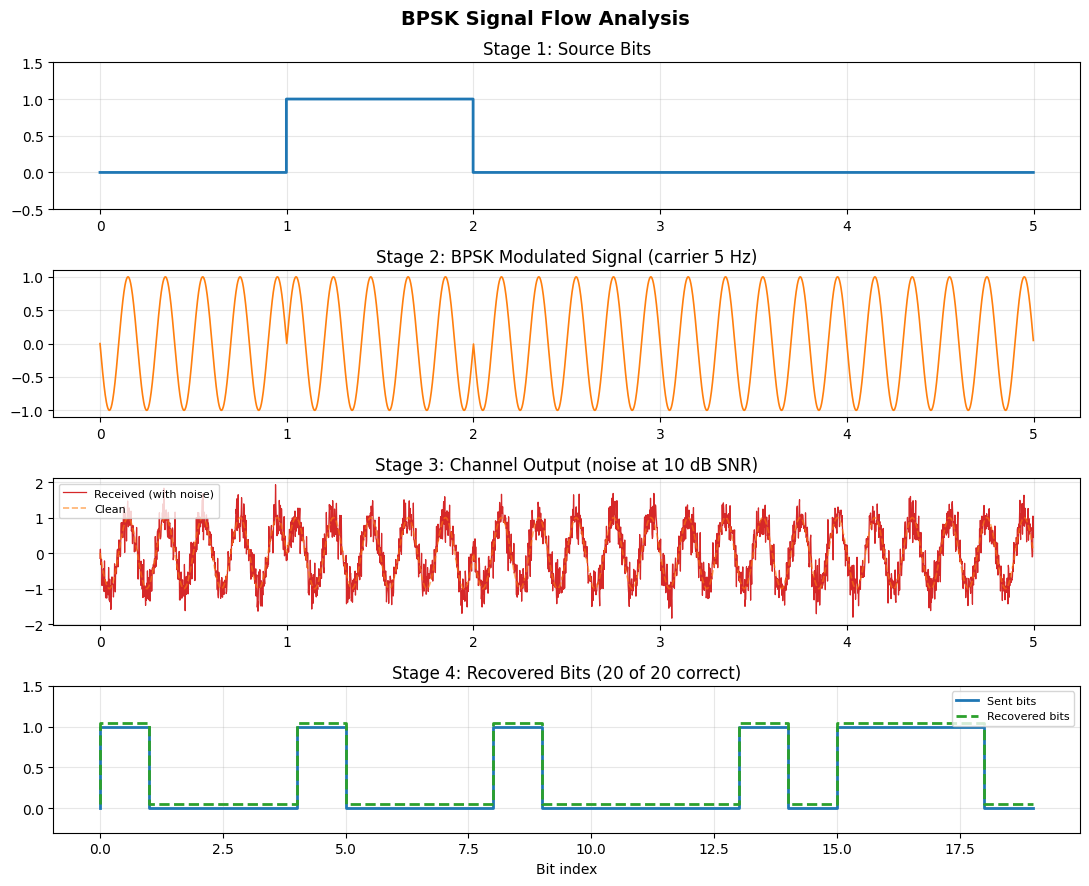

In [ ]:
# Plots the signal at each stage of the flow
window = 5 * fs          # shows the first five bits for the wave plots
t_win = t[:window]

fig, axes = plt.subplots(4, 1, figsize=(11, 9))
fig.suptitle("BPSK Signal Flow Analysis", fontsize=14, fontweight="bold")

# Stage 1
axes[0].step(t_win, bits_signal[:window], color="#1f77b4", linewidth=2)
axes[0].set_title("Stage 1: Source Bits")
axes[0].set_ylim(-0.5, 1.5)
axes[0].grid(True, alpha=0.3)

# Stage 2
axes[1].plot(t_win, modulated[:window], color="#ff7f0e", linewidth=1.2)
axes[1].set_title(f"Stage 2: BPSK Modulated Signal (carrier {fc} Hz)")
axes[1].grid(True, alpha=0.3)

# Stage 3
axes[2].plot(t_win, received[:window], color="#d62728", linewidth=0.9, label="Received (with noise)")
axes[2].plot(t_win, modulated[:window], color="#ff7f0e", linewidth=1.2, linestyle="--", alpha=0.6, label="Clean")
axes[2].set_title(f"Stage 3: Channel Output (noise at {snr_db} dB SNR)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Stage 4
axes[3].step(range(num_bits), bits, color="#1f77b4", linewidth=2, label="Sent bits")
axes[3].step(range(num_bits), recovered_bits + 0.05, color="#2ca02c", linewidth=2, linestyle="--", label="Recovered bits")
axes[3].set_title(f"Stage 4: Recovered Bits ({num_bits - errors} of {num_bits} correct)")
axes[3].set_ylim(-0.3, 1.5)
axes[3].set_xlabel("Bit index")
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Read from top to bottom, the four plots are the same message at four points in its journey: as plain bits, as a clean modulated wave, as a noisy received wave, and as the recovered bits. That progression, together with the fact that the bits come out matching the bits that went in, is the signal flow analysis the lab asks for.